In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

#### Exploring the Data

In [2]:
dataset_path = os.path.realpath(
    os.path.join(
        os.getcwd(),
        "..",
        "Radar",
        "C3"
    )
)
test_f_path = os.path.realpath(
    os.path.join(
        dataset_path,
        "U03",
        "E01",
        "01",
        "2.pkl",
    )
)
test_data = pd.read_pickle(test_f_path)
test_data

[array([[ 1.75302405e+09,  2.20507812e+00,  1.42578125e-01,
         -6.26953125e-01,  1.04139271e+01]]),
 array([[ 1.75302405e+09,  2.18164062e+00,  2.10937500e-01,
         -5.09765625e-01,  1.38021126e+01],
        [ 1.75302405e+09,  2.31054688e+00,  7.22656250e-02,
         -3.86718750e-01,  1.07918129e+01]]),
 array([[ 1.75302405e+09,  1.76367188e+00, -1.11328125e-01,
         -2.22656250e-01,  1.20411997e+01],
        [ 1.75302405e+09,  2.33203125e+00, -0.00000000e+00,
         -2.36328125e-01,  1.25527248e+01],
        [ 1.75302405e+09,  2.24218750e+00,  1.40625000e-01,
         -9.76562500e-02,  1.96848297e+01]]),
 array([[ 1.75302405e+09,  1.75390625e+00, -1.66015625e-01,
         -2.61718750e-01,  1.56820173e+01],
        [ 1.75302405e+09,  2.20117188e+00, -6.83593750e-02,
          5.85937500e-02,  1.97772369e+01],
        [ 1.75302405e+09,  2.34179688e+00, -0.00000000e+00,
         -8.78906250e-02,  1.56820173e+01],
        [ 1.75302405e+09,  2.07226562e+00, -0.00000000e+00

In [3]:
len(test_data)

169

In [4]:
test_data[0]

array([[ 1.75302405e+09,  2.20507812e+00,  1.42578125e-01,
        -6.26953125e-01,  1.04139271e+01]])

In [5]:
test_data[1]

array([[ 1.75302405e+09,  2.18164062e+00,  2.10937500e-01,
        -5.09765625e-01,  1.38021126e+01],
       [ 1.75302405e+09,  2.31054688e+00,  7.22656250e-02,
        -3.86718750e-01,  1.07918129e+01]])

In [6]:
for i in range(0, int(len(test_data)/12)):
    print(test_data[i].shape)

(1, 5)
(2, 5)
(3, 5)
(5, 5)
(4, 5)
(2, 5)
(1, 5)
(1, 5)
(1, 5)
(1, 5)
(3, 5)
(3, 5)
(2, 5)
(2, 5)


In [7]:
emotions = {
    "E01": "focus",
    "E02": "distraction",
    "E03": "stress",
    "E04": "relaxation",
    "E05": "depression",
    "E06": "excitement"
}

In [8]:
ceiling_radars= list(range(0, 5))
ground_radars = list(range(5, 13))

In [9]:
t = pd.read_pickle("/Users/anas/Docs/Project Course/Radar/C3/U03/E01/01/0.pkl")
np.vstack(t)

array([[ 1.75302405e+09,  1.75195312e+00, -2.00390625e+00,
         2.36328125e-01,  1.23044891e+01],
       [ 1.75302405e+09,  1.64257812e+00, -2.08789062e+00,
         2.85156250e-01,  1.34242268e+01],
       [ 1.75302405e+09,  1.91601562e+00, -1.98828125e+00,
         1.50390625e-01,  1.17609129e+01],
       ...,
       [ 1.75302417e+09,  2.00585938e+00, -1.90039062e+00,
         8.00781250e-02,  1.47712126e+01],
       [ 1.75302417e+09,  2.37500000e+00, -1.75390625e+00,
         8.00781250e-02,  1.30102997e+01],
       [ 1.75302417e+09,  1.94335938e+00, -2.02148438e+00,
         2.20703125e-01,  1.23044891e+01]], shape=(442, 5))

In [10]:
from matplotlib.path import Path


U = {}
users = []

for u in os.listdir(dataset_path):
    temp_emotions = []
    temp_movement_features = []

    if not u.startswith("U"):
        continue
    print(f"For user {u}:")
    users.append(u)
    for e in os.listdir(os.path.join(dataset_path, u)):
        if not e.startswith("E"):
            continue
        
        print(f"\tFor emotion {emotions[e]}:")
        emotion_label = emotions[e]
        temp_emotions.append(emotion_label)

        radar_folder = os.listdir(os.path.join(dataset_path, u, e))
        radar_idx = None
        for f in radar_folder:
            dir = os.path.join(dataset_path, u, e, f)

            if not os.path.isdir(dir):
                continue
            
            radar_files = os.listdir(dir)
            radar_idx = f
            break

        sequences_size = []
        for f in radar_files:
            file_path = os.path.join(dataset_path, u, e, radar_idx, f)
            data = pd.read_pickle(file_path)
            radar_used = ("CEILING" if int(f[0]) < 5 else "GROUND")
            sequence = np.vstack(data)
            fs = []

            for s in sequence:
                # RE ORDERING THE CEILING RADAR FEATURES TO MATCH 
                # THE ORDER IN `radar_ceiling.py`` script
                xyz = [s[1], s[2], s[3]]
                if radar_used == "CEILING":
                    xyz = [s[3], s[2], -s[1]]

                new_s = np.concatenate((xyz, s[4:5]))
                fs.append(new_s)  

            fs = np.array(fs)

            sequences_size.append(fs.shape[0])
            temp_movement_features.append([[radar_used] + list(fs)])
        
        print(f"\t\t Sequences length: {sequences_size} samples")

    U[u] = {
        "emotions": temp_emotions,
        "movement_features": temp_movement_features
    }

For user U53:
	For emotion stress:
		 Sequences length: [59, 225, 144, 212, 22, 54, 409, 239, 53, 22, 14, 7, 107] samples
	For emotion relaxation:
		 Sequences length: [127, 233, 209, 134, 57, 88, 883, 265, 61, 24, 3, 43, 96] samples
	For emotion depression:
		 Sequences length: [458, 992, 259, 200, 797, 171, 1009, 710, 127, 37, 249, 196] samples
	For emotion distraction:
		 Sequences length: [56, 235, 215, 191, 43, 110, 1306, 348, 115, 12, 13, 34, 143] samples
	For emotion focus:
		 Sequences length: [28, 96, 77, 124, 35, 54, 440, 164, 37, 9, 2, 14, 129] samples
	For emotion excitement:
		 Sequences length: [1025, 728, 554, 473, 361, 837, 2416, 1469, 362, 41, 1, 34, 334] samples
For user U54:
	For emotion stress:
		 Sequences length: [45, 81, 59, 70, 45, 7, 6, 1, 31, 49] samples
	For emotion relaxation:
		 Sequences length: [59, 112, 77, 129, 37, 51, 296, 318, 10, 7, 1, 27, 38] samples
	For emotion depression:
		 Sequences length: [928, 1710, 668, 235, 632, 221, 941, 1748, 275, 50, 27

In [88]:
emotions_count = {}

for user in U:
    for emotion in U[user]["emotions"]:
        if emotion not in emotions_count:
            emotions_count[emotion] = 0
        emotions_count[emotion] += 1

emotions_count

{'stress': 31,
 'relaxation': 31,
 'depression': 28,
 'distraction': 31,
 'focus': 31,
 'excitement': 29}

In [30]:
len(U["U03"]["movement_features"])

78

Every element of X is the sequence captured by a specific radar for a specific emotion of the same index.

In [89]:
x = U["U03"]["movement_features"][0][0][1:] 

df = pd.DataFrame(x, columns=["V1", "V2", "V3", "V4"])
df.describe()

,V1,V2,V3,V4
count,522.000000,522.000000,522.000000,522.000000
mean,2.633748,-0.064704,-0.334489,13.437849
std,0.177140,0.146049,0.213629,2.428390
min,2.095703,-0.527344,-1.750000,9.542425
25%,2.451172,-0.160156,-0.452637,11.461281
50%,2.702148,-0.000000,-0.320312,12.898918
75%,2.770996,-0.000000,-0.205078,14.771213
max,3.177734,0.527344,1.675781,21.139433


In [90]:
sample = []
for i in range(0, 12):
    sample += [U["U03"]["movement_features"][i][0][1:]]

#### Extracting motion features from radar data but keeping it simple

In [91]:
def compute_centroids(sample):
    centroids = []

    prev = np.zeros(3)

    for frame in sample:
        if len(frame) == 0:
            centroids.append(prev)
            continue

        frame = np.array(frame)
        pts = frame[:, :3]

        centroid = np.mean(pts, axis=0)

        centroids.append(centroid)
        prev = centroid

    return np.array(centroids)

In [153]:
def motion_features(centroids):
    if len(centroids) < 4:
        return [0]*7
    
    diffs = np.diff(centroids, axis=0)
    
    speed = np.linalg.norm(diffs, axis=1)
    
    acc = np.diff(speed)
    
    jerk = np.diff(acc)
    
    low_speed_threshold = 0.01
    low_speed_ratio = np.sum(speed < low_speed_threshold) / len(speed)
    
    return [
        np.mean(speed),
        np.std(speed),
        
        np.mean(acc),
        np.std(acc),
        
        np.mean(jerk),
        np.std(jerk),
        
        low_speed_ratio
    ]

In [154]:
def spread_features(sample):
    spreads = []
    
    for frame in sample:
        if len(frame) == 0:
            continue
    
        frame = np.array(frame)
        pts = frame[:,0:3]
        spreads.append(np.mean(np.linalg.norm(pts - np.mean(pts,axis=0),axis=1)))
    
    if len(spreads) == 0:
        return [0,0]
    
    return [
        np.mean(spreads),
        np.std(spreads)
    ]

In [166]:
def extract_features(sample):

    centroids = compute_centroids(sample)
    
    f_motion = motion_features(centroids)
    f_spread = spread_features(sample)
    
    return np.array(f_motion + f_spread)

feature_names = [
    "mean_speed", "speed_variance", "acc_mean", "acc_variance",
    "jerk_mean", "jerk_variance", "low_speed_ratio",
    "spread_mean", "spread_std"
]

#### Basic attempt with a random forest classifier

In [167]:
all_users_all_features = []
all_users_emotion_labels = []
user_ids = []
for u in U.keys():
    for i, val in enumerate(emotions.values()):
        samples = []
        j = i * 12
        max_j = (i + 1) * 12
        while j < max_j:
            if j >= len(U[u]["movement_features"]):
                break

            samples += [U[u]["movement_features"][j][0][1:]]
            j += 1

        features = extract_features(samples)
        all_users_all_features.append(features)
        all_users_emotion_labels.append(val)
        user_ids.append(u)

all_users_all_features = np.array(all_users_all_features)
all_users_emotion_labels = np.array(all_users_emotion_labels)
print(all_users_all_features.shape, len(all_users_emotion_labels))

(186, 9) 186


In [168]:
from sklearn.model_selection import GroupShuffleSplit

groups = np.array(user_ids)
gss = GroupShuffleSplit(test_size=0.2, n_splits=1)

for train_idx, test_idx in gss.split(all_users_all_features, all_users_emotion_labels, groups=user_ids):
    X_train, X_test = all_users_all_features[train_idx], all_users_all_features[test_idx]
    y_train, y_test = all_users_emotion_labels[train_idx], all_users_emotion_labels[test_idx]

In [171]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8809523809523809


In [172]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

  depression       1.00      0.86      0.92         7
 distraction       0.70      1.00      0.82         7
  excitement       1.00      1.00      1.00         7
       focus       1.00      0.86      0.92         7
  relaxation       0.86      0.86      0.86         7
      stress       0.83      0.71      0.77         7

    accuracy                           0.88        42
   macro avg       0.90      0.88      0.88        42
weighted avg       0.90      0.88      0.88        42

[[6 1 0 0 0 0]
 [0 7 0 0 0 0]
 [0 0 7 0 0 0]
 [0 0 0 6 0 1]
 [0 1 0 0 6 0]
 [0 1 0 0 1 5]]


In [174]:
import pandas as pd

importances = model.feature_importances_

df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

df

,feature,importance
2,acc_mean,0.253764
4,jerk_mean,0.215712
1,speed_variance,0.125656
3,acc_variance,0.104161
0,mean_speed,0.103353
5,jerk_variance,0.099215
7,spread_mean,0.052151
8,spread_std,0.045989
6,low_speed_ratio,0.000000


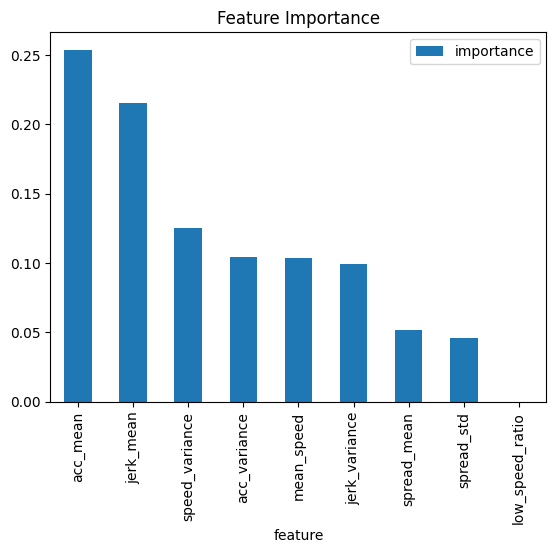

In [175]:
df.plot.bar(x="feature", y="importance")
plt.title("Feature Importance")
plt.show()

#### Building on top of the simple stastics, we can try to use the more complex motions as features for a simple classifier.

In [114]:
def trajectory_length(centroids):
    diffs = np.diff(centroids, axis=0)
    distances = np.linalg.norm(diffs, axis=1)
    return np.sum(distances)

In [115]:
def displacement(centroids):
    return np.linalg.norm(centroids[-1] - centroids[0])

In [116]:
def path_efficiency(centroids):
    path_len = trajectory_length(centroids)

    if path_len == 0:
        return 0

    disp = displacement(centroids)

    return disp / path_len

In [117]:
def bounding_box_volume(centroids):
    mins = np.min(centroids, axis=0)
    maxs = np.max(centroids, axis=0)

    dims = maxs - mins

    return np.prod(dims)

In [140]:
def movement_anisotropy(centroids):
    n_samples, n_features = centroids.shape
    n_components = min(n_samples, n_features)
    pca = PCA(n_components=n_components)
    pca.fit(centroids)

    var = pca.explained_variance_ratio_

    return var[0]

In [141]:
def mean_turning_angle(centroids):
    v1 = np.diff(centroids[:-1], axis=0)
    v2 = np.diff(centroids[1:], axis=0)

    norms1 = np.linalg.norm(v1, axis=1)
    norms2 = np.linalg.norm(v2, axis=1)

    valid = (norms1 > 1e-6) & (norms2 > 1e-6)

    v1 = v1[valid]
    v2 = v2[valid]

    norms1 = norms1[valid]
    norms2 = norms2[valid]

    cos_angles = np.sum(v1 * v2, axis=1) / (norms1 * norms2)

    cos_angles = np.clip(cos_angles, -1, 1)

    angles = np.arccos(cos_angles)

    return np.mean(angles)

In [124]:
def motion_bursts(speed, threshold=None):
    if threshold is None:
        threshold = np.mean(speed) + np.std(speed)

    active = speed > threshold

    bursts = np.diff(active.astype(int)) == 1

    return np.sum(bursts)

In [144]:
def motion_peaks(speed):
    if len(speed) < 3:
        return 0, 0, 0

    acc = np.diff(speed)
    jerk = np.diff(acc)

    return max(speed), max(acc), max(jerk)

In [190]:
def extract_features(sample):
    centroids = compute_centroids(sample)
    
    if centroids.ndim != 2 or len(centroids) < 2:
        print("Not enough centroids to compute features.")
        return [0.0] * 10
    
    diffs = np.diff(centroids, axis=0)

    speed = np.linalg.norm(diffs, axis=1)
    max_speed, max_acc, max_jerk = motion_peaks(speed)

    return [
        trajectory_length(centroids),
        displacement(centroids),
        path_efficiency(centroids),
        bounding_box_volume(centroids),
        movement_anisotropy(centroids),
        mean_turning_angle(centroids),
        motion_bursts(speed),
        max_speed,
        max_acc,
        max_jerk
    ]

feature_names = [
    "trajectory_length",
    "displacement",
    "path_efficiency",
    "bounding_box_volume",
    "movement_anisotropy",
    "mean_turning_angle",
    "motion_bursts",
    "max_speed",
    "max_acc",
    "max_jerk"
]

#### Again with the basic random forest

In [191]:
all_users_all_features = []
all_users_emotion_labels = []
user_ids = []
for u in U.keys():
    for i, val in enumerate(emotions.values()):
        samples = []
        j = i * 12
        max_j = (i + 1) * 12
        while j < max_j:
            if j >= len(U[u]["movement_features"]):
                break

            samples += [U[u]["movement_features"][j][0][1:]]
            j += 1

        features = extract_features(samples)
        all_users_all_features.append(features)
        all_users_emotion_labels.append(val)
        user_ids.append(u)

all_users_all_features = np.array(all_users_all_features)
all_users_emotion_labels = np.array(all_users_emotion_labels)
print(all_users_all_features.shape, len(all_users_emotion_labels))

Not enough centroids to compute features.
Not enough centroids to compute features.
(186, 10) 186


In [192]:
groups = np.array(user_ids)
gss = GroupShuffleSplit(test_size=0.2, n_splits=1)

for train_idx, test_idx in gss.split(all_users_all_features, all_users_emotion_labels, groups=user_ids):
    X_train, X_test = all_users_all_features[train_idx], all_users_all_features[test_idx]
    y_train, y_test = all_users_emotion_labels[train_idx], all_users_emotion_labels[test_idx]

In [193]:
model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8571428571428571


In [194]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

  depression       1.00      1.00      1.00         7
 distraction       1.00      1.00      1.00         7
  excitement       0.86      0.86      0.86         7
       focus       1.00      0.86      0.92         7
  relaxation       0.67      0.86      0.75         7
      stress       0.67      0.57      0.62         7

    accuracy                           0.86        42
   macro avg       0.87      0.86      0.86        42
weighted avg       0.87      0.86      0.86        42

[[7 0 0 0 0 0]
 [0 7 0 0 0 0]
 [0 0 6 0 0 1]
 [0 0 0 6 1 0]
 [0 0 0 0 6 1]
 [0 0 1 0 2 4]]


In [195]:
importances = model.feature_importances_

df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

df

,feature,importance
2,path_efficiency,0.183604
1,displacement,0.164545
4,movement_anisotropy,0.131930
0,trajectory_length,0.125029
9,max_jerk,0.077860
3,bounding_box_volume,0.077438
8,max_acc,0.065354
5,mean_turning_angle,0.063898
7,max_speed,0.057801
6,motion_bursts,0.052540


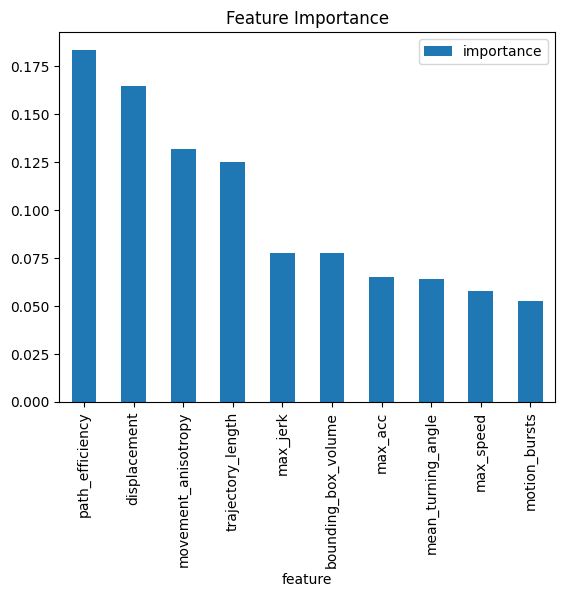

In [196]:
df.plot.bar(x="feature", y="importance")
plt.title("Feature Importance")
plt.show()

#### Extending from working with the entire frame per emotion to splitting the frame into smaller sequences and extracting features from those sequences. This should give us more data to work with and hopefully improve the performance of our model. (Next notebook)

In [ ]:
def window_features(sample, window_size, stride):
    centroids = compute_centroids(sample)
    
    if len(centroids) < window_size:
        return None

    all_features = []

    for start in range(0, len(centroids) - window_size + 1, stride):

        window = centroids[start:start + window_size]

        feats = extract_features(window)

        all_features.append(feats)

    all_features = np.array(all_features)

    aggregated = np.concatenate([
        np.mean(all_features, axis=0),
        np.std(all_features, axis=0),
        np.max(all_features, axis=0),
        np.min(all_features, axis=0)
    ])

    return aggregated